# 06_NarrativeRisk_LLM_SeverityDistribution

Inspection-only quantlet: no portfolio formation. Plots histograms and heatmaps of the 30x10x10 severity panel by year, GICS sector, and theme. Surfaces dataset structure (severity drift over time, sector concentration of risk themes) so downstream quantlet readers see the underlying signal distribution before consuming derived statistics.

**Axis exercised:** Corpus inspection by year x sector x theme

Headline numbers reported below are **indicative not inferential** at N=30 firms x 10 fiscal years and are **not intended as evidence**.


## Why a corpus-inspection quantlet exists

Every other quantlet in this family produces an alpha estimate.
Reading those alphas in isolation is a methodological trap.
A reader who jumps directly to quantlet 01's tercile spread without first inspecting the underlying severity panel cannot tell whether the spread is well-supported or driven by a handful of extreme cells; the headline alpha summarises a distribution before the reader has seen the distribution itself.

This quantlet addresses that gap.
It loads the same 30 firms x 10 years x 10 themes severity panel that every other quantlet consumes (modulo synthetic-versus-real data) and visualises it directly.
There is no portfolio formation, no regression, no FF5+UMD residual; the output is a 4-panel diagnostic figure plus a per-theme summary CSV.

The four panels answer four distinct questions about the input signal: how does mean severity vary jointly across themes and years; what does the panel-wide distribution of severity 0..5 look like; how does the per-theme severity drift across the 10-year window; and how does mean severity differ across GICS sectors when sector mapping is available.
None of these is a substitute for the alpha-producing quantlets; all of them are pre-conditions for reading those quantlets' headlines responsibly.


## When to read this quantlet

The recommended sequence is: read this quantlet first (corpus inspection), then quantlet 01 (real-data alpha headline), then any of the methodology-axis quantlets (02 through 10) depending on which axis the reader cares about.

A reader who only inspects quantlet 01 in isolation has no view on the underlying signal distribution and cannot tell whether the headline spread is supported by smooth cross-sectional variation or driven by a handful of extreme cells.
A reader who inspects 06 first sees the signal directly and reads 01's headline in context.

The four-panel figure is also useful for a second pass after reading the alpha-producing quantlets: returning to it after reading quantlet 08's industry-neutral alpha lets the reader see whether the alpha contraction (if any) is consistent with the sector concentration visible in panel (d).
The diagnostic value of corpus inspection is highest at the start of the family; it remains useful as a cross-reference throughout.

A practical reading rule: if any single panel surprises the reader (a theme whose severity is uniformly zero across the 10-year window, a sector-theme cell that is dramatically above the rest of the heatmap, a year whose mean severity drops to near zero across all themes), pause before continuing to the alpha-producing quantlets.
The surprise often reveals a corpus-level data issue (failed extraction, mis-attributed theme, off-by-one year shift in the loader) that no downstream alpha test can recover from.
The cheapest place to detect that issue is here, before the alpha numbers get written into pinned-headline test files and propagated downstream.


## What this quantlet does

This is an **inspection-only** quantlet: it forms no portfolio, computes no spread, and reports no alpha. Instead it visualises the underlying severity panel (30 firms x 10 fiscal years x 10 themes ~ 3000 cells) so readers of the other 9 quantlets can see the distribution of the input signal.


In [1]:
from __future__ import annotations

import csv
import gzip
import json
import re
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()


In [2]:
from data import (
    CORPUS_PATH,
    load_corpus,
)


In [3]:
FIRM_LIST_PATH = HERE / "firm_list.csv"      # GICS sector mapping (optional for plot d)
PROVENANCE_PATH = HERE / "provenance.json"   # audit trail (not read at runtime; ships for transparency)
SUMMARY_OUT = HERE / "severity_distribution_summary.csv"
FIGURE_OUT = HERE / "severity_distribution.pdf"


In [4]:
def severity_summary_table(corpus_df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-theme descriptive statistics across all (firm, year) pairs.

    Returns a DataFrame with rows = themes (theme_label) and cols:
    [mean, median, p25, p75, std], all rounded to 3 decimal places.
    """
    stats = (
        corpus_df.groupby("theme_label")["severity_0_5"]
        .agg(
            mean=lambda s: round(s.mean(), 3),
            median=lambda s: round(s.median(), 3),
            p25=lambda s: round(s.quantile(0.25), 3),
            p75=lambda s: round(s.quantile(0.75), 3),
            std=lambda s: round(s.std(ddof=1), 3),
        )
    )
    stats.index.name = "theme"
    return stats


def _load_sector_map(firm_list_path: Path = FIRM_LIST_PATH):
    """Load firm -> GICS sector mapping from firm_list.csv if the file exists.

    Returns a DataFrame with columns [firm, sector], or None when the file is absent.
    """
    if not firm_list_path.exists():
        return None
    df = pd.read_csv(firm_list_path, usecols=["ticker", "sector"])
    return df.rename(columns={"ticker": "firm"})


def plot_severity_grid(
    corpus_df: pd.DataFrame,
    out_path: Path = None,
    close: bool = True,
):
    """Produce a 2x2 subplot figure and save as PDF (and PNG sidecar if suffix differs).

    Sub-panels:
      (a) Heatmap: theme (rows) x year (cols), cell = mean severity across firms.
      (b) Histogram: overall integer count of each severity level 0..5.
      (c) Time series: mean severity per year, one line per theme (10 lines).
      (d) Sector heatmap: theme (rows) x GICS sector (cols), cell = mean severity.
          If firm_list.csv is absent the panel shows a placeholder note.

    Returns the matplotlib Figure so notebook cells can display it inline.
    """
    if out_path is None:
        out_path = FIGURE_OUT
    sector_map = _load_sector_map()

    themes = sorted(corpus_df["theme_label"].unique())
    years = sorted(corpus_df["year"].unique())

    # --- Sub-panel data ---

    # (a) Heatmap data: theme x year, mean severity
    heatmap_a = (
        corpus_df.groupby(["theme_label", "year"])["severity_0_5"]
        .mean()
        .unstack("year")
        .reindex(index=themes)
    )

    # (b) Histogram data: count per integer severity 0..5
    hist_counts = corpus_df["severity_0_5"].value_counts().sort_index()

    # (c) Time-series data: mean severity per year per theme
    ts_data = (
        corpus_df.groupby(["year", "theme_label"])["severity_0_5"]
        .mean()
        .unstack("theme_label")
        .reindex(columns=themes)
    )

    # (d) Sector heatmap data (only when firm_list.csv present)
    if sector_map is not None:
        merged = corpus_df.merge(sector_map, on="firm", how="left")
        heatmap_d = (
            merged.groupby(["theme_label", "sector"])["severity_0_5"]
            .mean()
            .unstack("sector")
            .reindex(index=themes)
        )
    else:
        heatmap_d = None

    # --- Figure layout ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        "Severity panel: 30 firms × 10 years × 10 themes (severity 0–5)\n"
        "Indicative not inferential",
        fontsize=11,
    )

    # (a) Theme × Year heatmap
    ax_a = axes[0, 0]
    im_a = ax_a.imshow(heatmap_a.values, aspect="auto", vmin=0, vmax=5, cmap="YlOrRd")
    ax_a.set_xticks(range(len(years)))
    ax_a.set_xticklabels([str(y) for y in years], rotation=45, ha="right", fontsize=8)
    ax_a.set_yticks(range(len(themes)))
    ax_a.set_yticklabels(themes, fontsize=7)
    ax_a.set_title("(a) Mean severity by theme × year", fontsize=9)
    fig.colorbar(im_a, ax=ax_a, fraction=0.03, pad=0.04)

    # (b) Severity histogram
    ax_b = axes[0, 1]
    severity_levels = list(range(6))
    counts = [int(hist_counts.get(s, 0)) for s in severity_levels]
    bars = ax_b.bar(severity_levels, counts, color="steelblue", edgecolor="white")
    ax_b.set_xlabel("Severity level (0 = none, 5 = critical)", fontsize=8)
    ax_b.set_ylabel("Count (panel-wide)", fontsize=8)
    ax_b.set_title("(b) Panel-wide severity distribution", fontsize=9)
    ax_b.set_xticks(severity_levels)
    for bar, cnt in zip(bars, counts):
        ax_b.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(cnt),
            ha="center",
            va="bottom",
            fontsize=7,
        )

    # (c) Time series: one line per theme
    ax_c = axes[1, 0]
    cmap_10 = plt.get_cmap("tab10")
    for i, theme in enumerate(themes):
        if theme in ts_data.columns:
            ax_c.plot(
                ts_data.index,
                ts_data[theme].values,
                label=theme,
                linewidth=1.4,
                color=cmap_10(i),
            )
    ax_c.set_xlabel("Year", fontsize=8)
    ax_c.set_ylabel("Mean severity (across 30 firms)", fontsize=8)
    ax_c.set_title("(c) Mean severity per year by theme", fontsize=9)
    ax_c.legend(fontsize=6, ncol=2, loc="upper left")
    ax_c.grid(True, alpha=0.25)

    # (d) Sector heatmap
    ax_d = axes[1, 1]
    if heatmap_d is not None:
        sectors = list(heatmap_d.columns)
        im_d = ax_d.imshow(heatmap_d.values, aspect="auto", vmin=0, vmax=5, cmap="YlOrRd")
        ax_d.set_xticks(range(len(sectors)))
        ax_d.set_xticklabels(sectors, rotation=45, ha="right", fontsize=7)
        ax_d.set_yticks(range(len(themes)))
        ax_d.set_yticklabels(themes, fontsize=7)
        ax_d.set_title("(d) Mean severity by theme × GICS sector", fontsize=9)
        fig.colorbar(im_d, ax=ax_d, fraction=0.03, pad=0.04)
    else:
        ax_d.axis("off")
        ax_d.text(
            0.5,
            0.5,
            "firm_list.csv not found.\nSee README.md for instructions.",
            ha="center",
            va="center",
            fontsize=10,
            transform=ax_d.transAxes,
        )
        ax_d.set_title("(d) Sector heatmap — see README", fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save PDF (primary output)
    fig.savefig(out_path, bbox_inches="tight")

    # Save PNG sidecar automatically
    png_path = out_path.with_suffix(".png")
    if png_path != out_path:
        fig.savefig(png_path, bbox_inches="tight", dpi=150)

    if close:
        plt.close(fig)
    return fig


In [5]:
corpus = load_corpus()
print(f"corpus rows: {len(corpus)}; firms: {corpus['firm'].nunique()}; "
      f"years: {sorted(corpus['year'].unique())}; "
      f"themes: {corpus['theme_id'].nunique()}")
corpus.head(10)


corpus rows: 3000; firms: 30; years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]; themes: 10


,firm,year,theme_id,theme_label,severity_0_5,evidence_quote
0,AAPL,2015,T01,supply-chain,5,substantially all of its manufacturing is perf...
1,AAPL,2015,T02,regulatory,3,The Company is subject to laws and regulations...
2,AAPL,2015,T03,cyber,3,such insurance coverage may be insufficient to...
3,AAPL,2015,T04,macroeconomic,3,macroeconomic factors affecting consumer spend...
4,AAPL,2015,T05,climate,1,"natural disasters, whether as a result of clim..."
5,AAPL,2015,T06,competition,4,The Company's products and services compete in...
6,AAPL,2015,T07,litigation,3,"the Company's competitors, frequently enter in..."
7,AAPL,2015,T08,talent,3,"competition for their talents is intense, espe..."
8,AAPL,2015,T09,input-cost,3,subject to industry-wide shortages and signifi...
9,AAPL,2015,T10,technology,4,highly competitive and subject to rapid techno...


## Severity distribution

Counts of severity 0..5 across the panel give the baseline distribution. A right-skewed pile at 0/1 indicates most disclosures are boilerplate; a fatter tail at 4/5 indicates concentrated risk language.


In [6]:
summary = severity_summary_table(corpus)
print('=== severity counts (panel-wide) ===')
print(summary)
summary.to_csv(SUMMARY_OUT)


=== severity counts (panel-wide) ===
                mean  median  p25  p75    std
theme                                        
climate        1.380     1.0  0.0  2.0  1.134
competition    3.207     3.0  3.0  4.0  1.138
cyber          2.587     3.0  2.0  4.0  1.445
input-cost     1.760     2.0  1.0  3.0  1.273
litigation     2.843     3.0  2.0  4.0  1.037
macroeconomic  2.997     3.0  3.0  4.0  1.023
regulatory     3.573     3.5  3.0  5.0  1.065
supply-chain   2.160     2.0  1.0  3.0  1.412
talent         2.113     2.0  2.0  3.0  1.079
technology     2.807     3.0  2.0  4.0  1.345


## What to look for in the four panels

Panel (a), the theme x year heatmap, surfaces severity drift over time.
A theme whose mean severity systematically rises across 2015-2024 indicates a topic the LLM is increasingly identifying in Item 1A disclosures (cybersecurity, climate, AI exposure are common candidates); a theme whose severity declines indicates the opposite.
Drift across the 10-year window is informative because the cross-sectional sort treats each year independently; if a theme's mean severity trends, the within-year ranking remains valid but the across-year level comparison does not.

Panel (b), the panel-wide severity histogram, gives the integer distribution of severity 0..5.
A right-skewed pile at 0 and 1 indicates most disclosures are boilerplate or absent on most themes; a fatter tail at 4 and 5 indicates concentrated severe-language cells.
The shape of this histogram constrains how much cross-sectional variation is available for the tercile sort: if 90% of cells are at severity 0 or 1, the composite signal has limited cross-sectional discrimination, regardless of how many themes are summed.

Panel (c), the per-theme time-series, traces each of the 10 themes over time as one line.
Read this for theme-level dynamics that the joint heatmap might smear: a theme whose mean severity spikes in a single year and reverts is informative differently from one that monotonically trends.

Panel (d), the theme x GICS sector heatmap, surfaces sector concentration.
A theme whose mean severity is heavily concentrated in one sector (e.g., regulatory risk language concentrated in financials, climate risk language concentrated in energy and utilities) tells you the theme is partially proxying for sector membership.
This is the diagnostic motivating quantlet 08 (industry-neutral): if you see strong sector concentration in panel (d), reading quantlet 08's within-sector demean alpha is the natural next step.

None of the four panels constitute "evidence" in the asset-pricing sense; all of them constitute "context" for reading downstream alpha estimates responsibly.


## Year x theme heatmap

Mean severity per (year, theme) shows whether a particular risk theme drifts in tone across the 10-year window (e.g. cybersecurity in 2015 vs 2024).


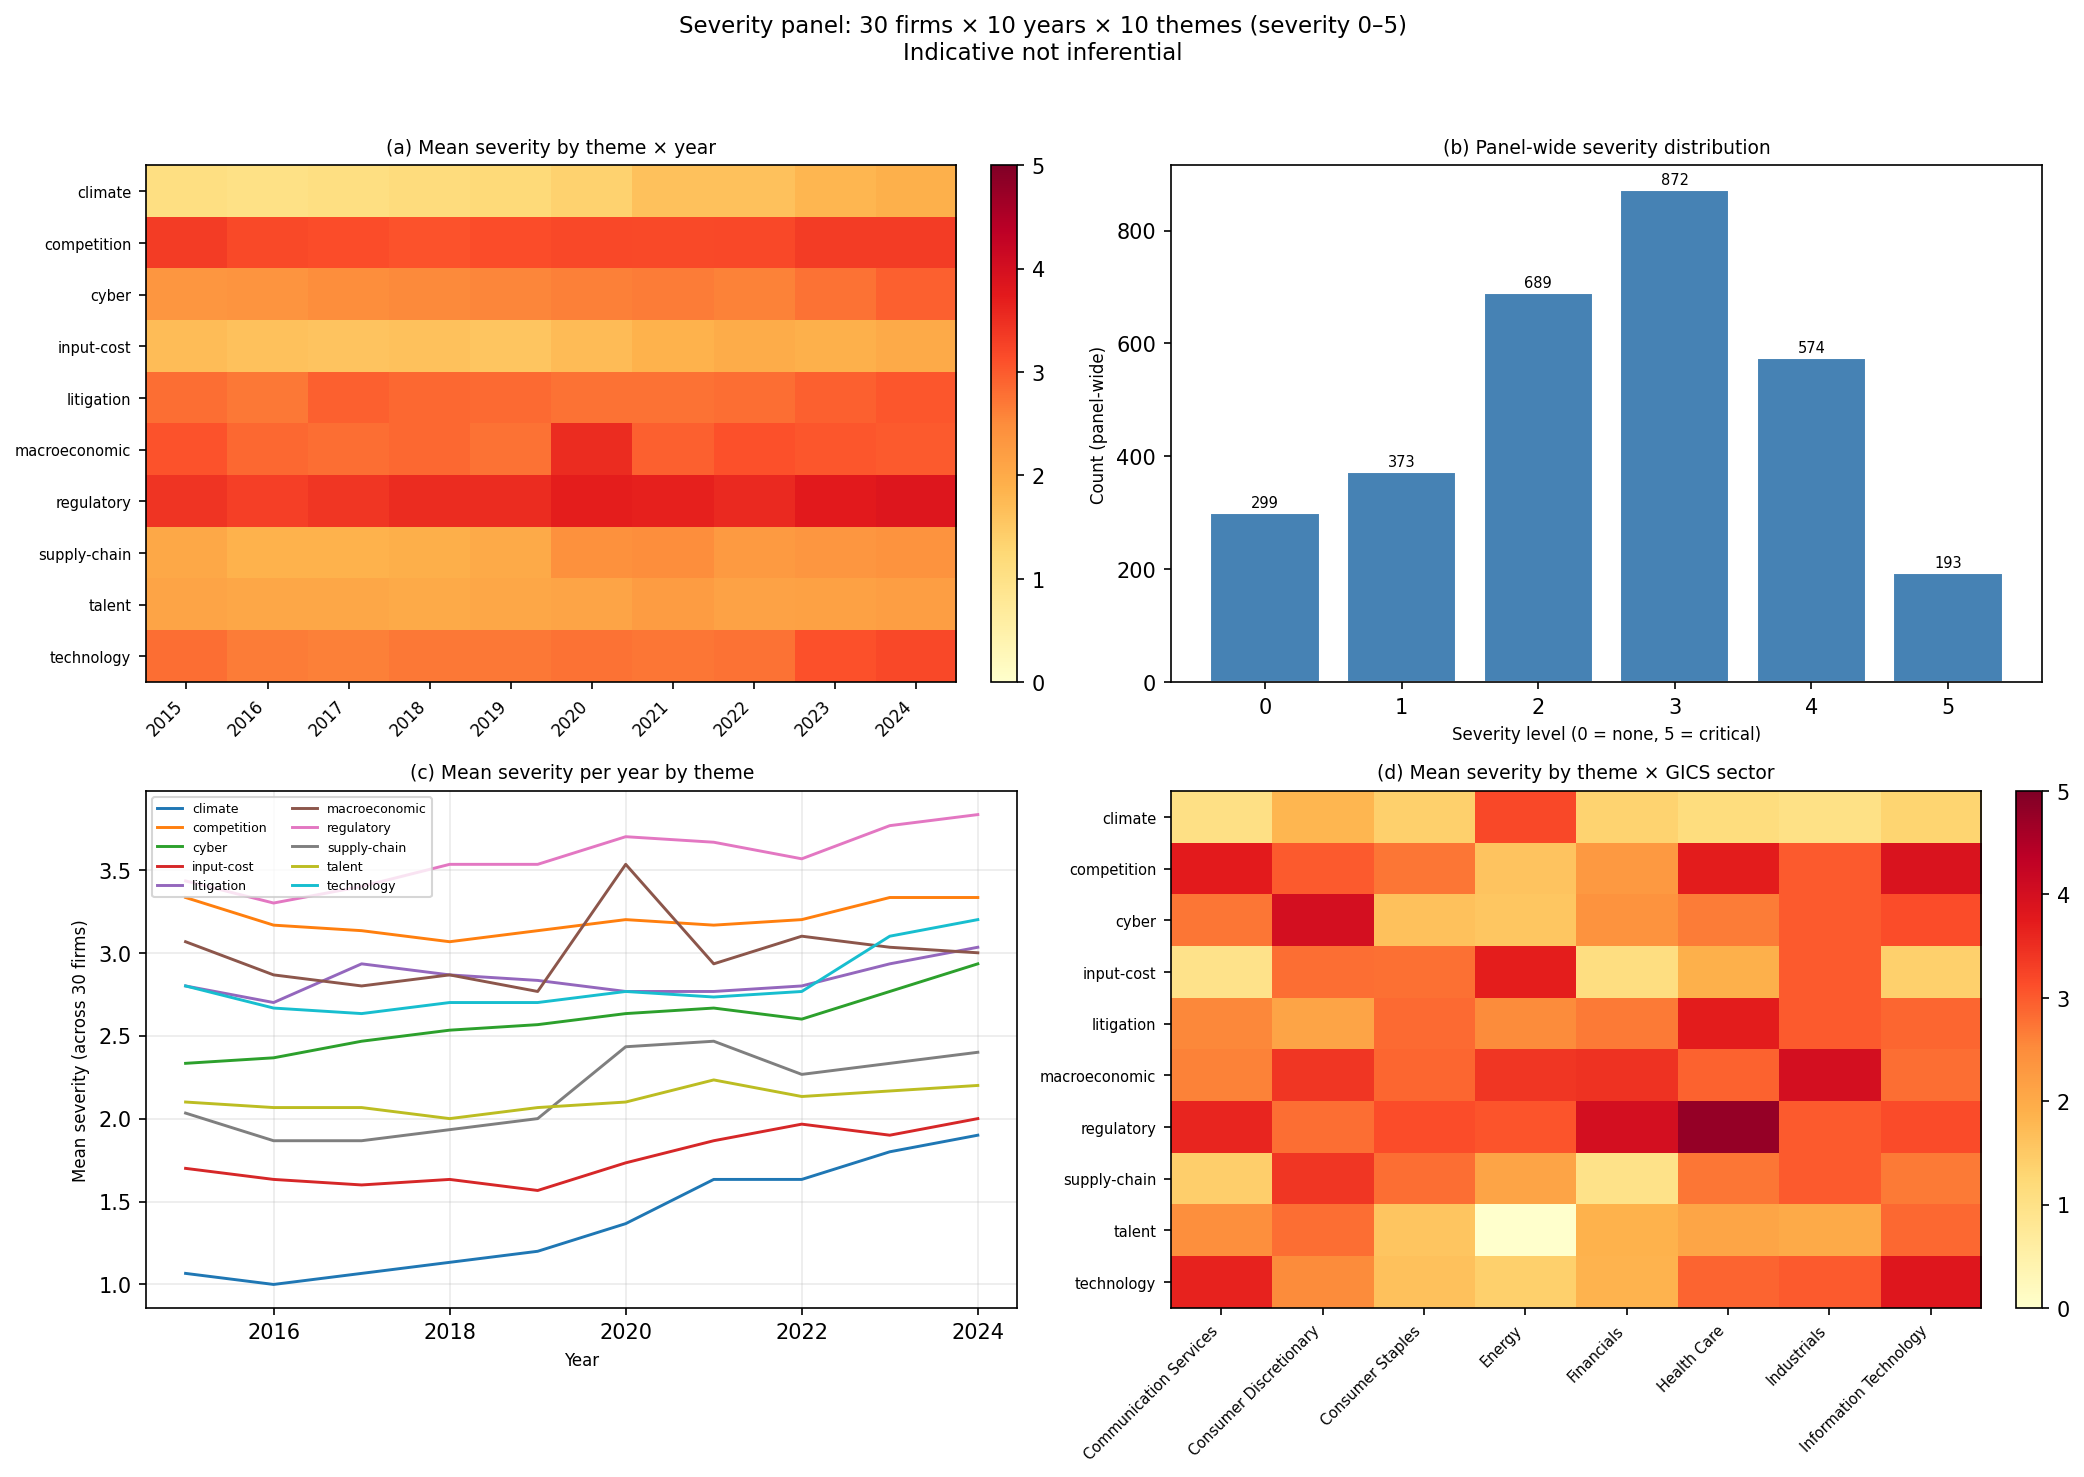

In [7]:
plot_severity_grid(corpus, out_path=FIGURE_OUT)
png_path = FIGURE_OUT.with_suffix('.png')
display(Image(filename=str(png_path)))


## Caveats

- **Power**: 30 firms split across 3 terciles leaves 10 firms per leg, statistically thin.
- **Severity validity**: severities are LLM (or LM) judgements of disclosure language; not validated against expert ratings or external risk benchmarks.
- **Taxonomy**: the 10-theme list is hand-listed and illustrative; production use would require a data-driven taxonomy.
- **Reproducibility**: `provenance.json` + `extraction_prompt.md` + the `corpus.ndjson.gz` SHA chain enable a full audit of how every severity was produced.


## Reproduction

```
git clone <repo>
cd 06_NarrativeRisk_LLM_SeverityDistribution
make data                  # fetch third-party data + regenerate seed-pinned inputs
make demo                  # this notebook -> severity_distribution_summary.csv + severity_distribution.pdf + severity_distribution.png
make test-all              # quantlet test suite
```
